In [2]:
import tensorflow as tf

In [16]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_encoder(input_shape=(64, 40, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    return Model(inputs, x, name="encoder")

def build_siamese_model(input_shape=(64, 40, 3)):
    encoder = build_encoder(input_shape)
    input_a = layers.Input(shape=input_shape, name='input_a')
    input_b = layers.Input(shape=input_shape, name='input_b')

    emb_a = encoder(input_a)
    emb_b = encoder(input_b)

    diff = layers.Lambda(
        lambda tensors: tf.abs(tensors[0] - tensors[1]),
        output_shape=(64,)
    )([emb_a, emb_b])
    x = layers.Dense(32, activation='relu')(diff)
    x = layers.Dense(1, activation='sigmoid')(x)  # Wyjście: prawdopodobieństwo tej samej postaci

    return Model([input_a, input_b], x)

In [3]:
def show_imgs(img1, img2):
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img1)
    axs[0].set_title('Obraz 1')
    axs[0].axis('off')

    axs[1].imshow(img2)
    axs[1].set_title('Obraz 2')
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [4]:
def preprocess_image(img, img_size=(64, 40)):
    img = tf.image.resize(img, img_size)

    img = tf.cast(img, tf.float32) / 255.0

    return img

In [9]:
def segmentate_captcha(captcha_img):
    h, w = captcha_img.shape[:2]
    cell_w = w // 6
    cell_h = h // 2

    segments = []
    for row in range(2):
        for col in range(6):
            x0 = col * cell_w
            y0 = row * cell_h
            segment = captcha_img[y0:y0+cell_h, x0:x0+cell_w]
            segments.append(segment)

    pairs = {
        'A': (segments[0], segments[3]),   # A: 1 i 7
        'B': (segments[1], segments[4]),   # B: 2 i 8
        'C': (segments[2], segments[5]),   # C: 3 i 9
        'D': (segments[6], segments[9]),   # D: 4 i 10
        'E': (segments[7], segments[10]),  # E: 5 i 11
        'F': (segments[8], segments[11]),  # F: 6 i 12
    }
    return pairs

In [17]:
from tensorflow.keras.layers import Lambda
from tensorflow.keras.models import load_model
import tensorflow as tf
from keras.config import enable_unsafe_deserialization
enable_unsafe_deserialization()

model = build_siamese_model(input_shape=(64, 40, 3))
model.load_weights('compare_two_modelv2.1.weights.h5')

def comapre_two(img1, img2):
    prob = model.predict([img1, img2])
    return prob[0][0] > 0.5

In [18]:
def solve_captcha(captcha_img):
    pairs = segmentate_captcha(captcha_img)
    results = []

    for k, v in pairs.items():
        img1, img2 = v

        img1 = preprocess_image(img1)
        img2 = preprocess_image(img2)

        show_imgs(img1.numpy(), img2.numpy())

        img1 = tf.expand_dims(img1, axis=0)
        img2 = tf.expand_dims(img2, axis=0)

        identical = comapre_two(img1, img2)

        if identical:
            results.append(k)

    return results

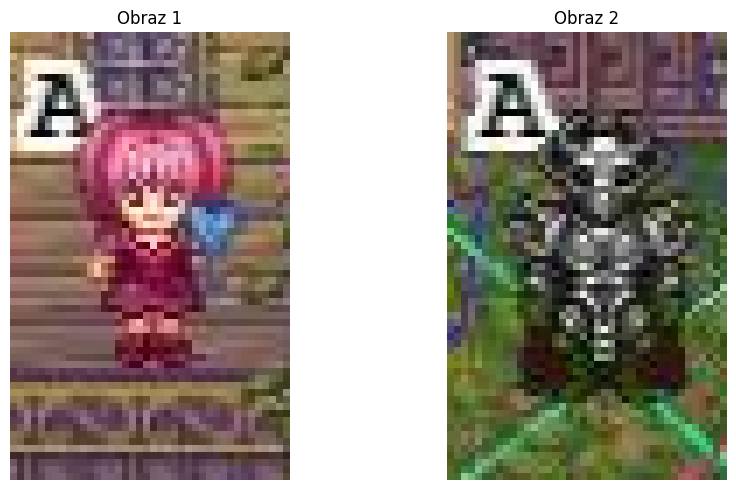

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


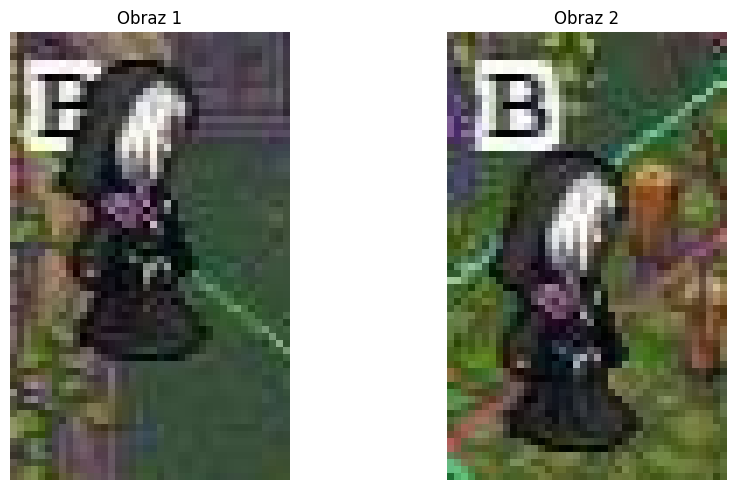

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


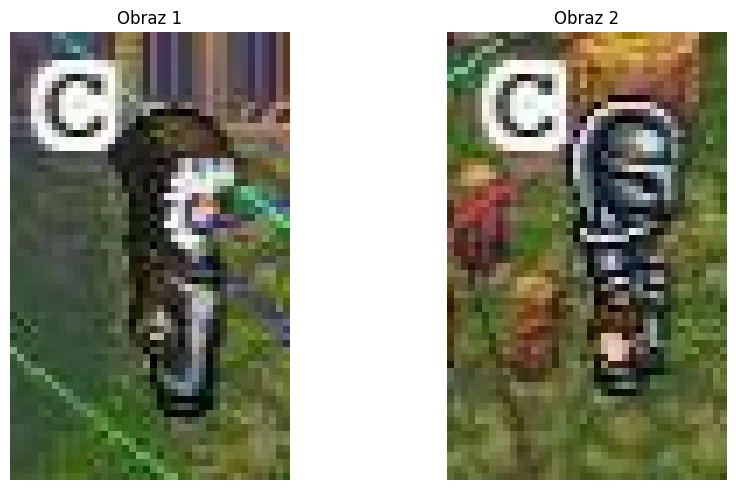

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


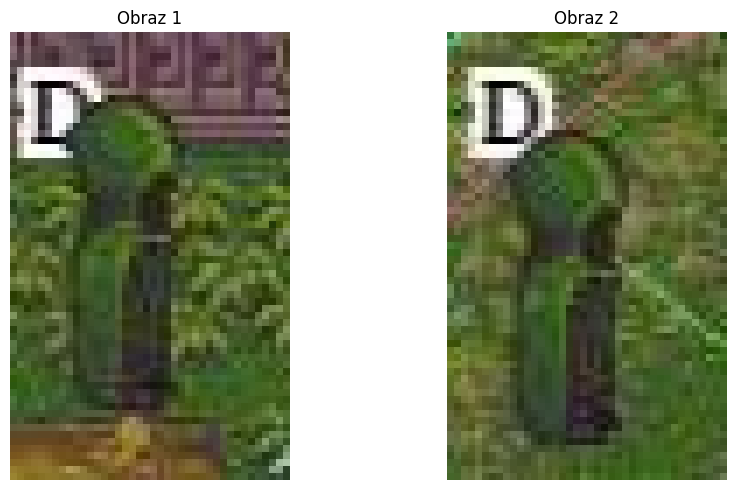

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


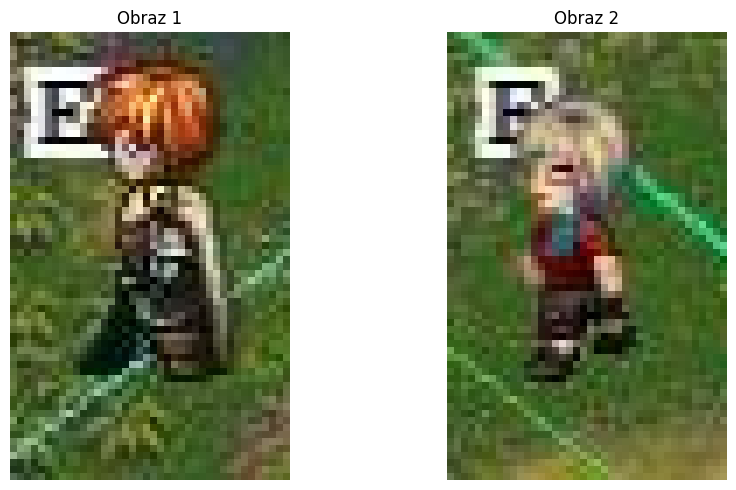

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


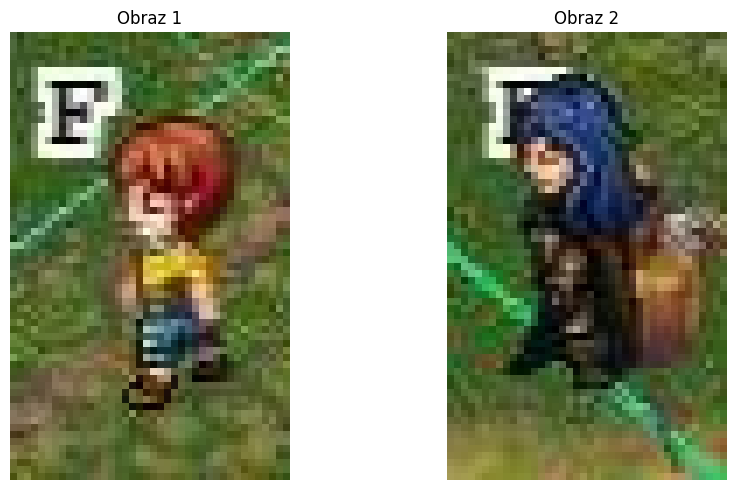

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Rozwiązanie CAPTCHA: ['B', 'C', 'D']


In [32]:
if __name__ == "__main__":
    captcha_img = tf.io.read_file('../data/captcha/game_probes/s14.jpg')
    captcha_img = tf.image.decode_jpeg(captcha_img, channels=3)

    result = solve_captcha(captcha_img)
    print("Rozwiązanie CAPTCHA:", result)